# Physics-informed learning across stacks — part 3: the plant as an FMI co-simulation FMU

**Series.** This is the final part of *Physics-informed learning across stacks*, a three-part series pairing **jaxonomy** (JAX — the physics lives inside a differentiable ODE/DAE solver) with **[NEUROMANCER](https://github.com/pnnl/neuromancer)** (PyTorch, from PNNL — the physics lives in the loss function and the network architecture). One physical system, a two-tank pump-and-valve network, runs through all three parts; what changes is *where the framework boundary sits*:

- **Pattern A — policy export** ([part 1](pinn_across_stacks_part_1_policy_export.ipynb)): a control policy trained in NEUROMANCER crosses into jaxonomy as a frozen ONNX graph. No gradients cross the boundary.
- **Pattern B — gradients across the boundary** ([part 2](pinn_across_stacks_part_2_neural_dae.ipynb)): the jaxonomy plant sits *inside* the PyTorch training loop, and exact vector-Jacobian products flow across the framework boundary.
- **Pattern C — co-simulation via FMI** (**this part**): the jaxonomy plant is exported as an FMI 2.0 co-simulation FMU and driven in lockstep by the PyTorch policy. Tool-neutral and gradient-free — the pattern for validation, certification workflows, and hardware-in-the-loop preparation.

![Three integration patterns: A exports a frozen ONNX policy into jaxonomy; B passes gradients between a jaxonomy plant and a NEUROMANCER training loop via dlpack; C couples a jaxonomy plant FMU to a PyTorch policy through the gradient-free FMI boundary.](media/pinn_across_stacks_patterns.svg)

> **A note on the word "PINN".** jaxonomy deliberately does not implement classical PDE PINNs — neural fields trained on residual losses over a spatial domain (see the [scope note](../scope/pinn.md)). Everything in this series is *physics-informed dynamics learning*: the physics constraint is enforced by simulating a dynamical system forward in time.

**This part.** We take the exact two-tank plant of parts 1 and 2, package it as a standards-compliant FMI 2.0 co-simulation FMU with `jaxonomy.library.fmu_export.build_fmu`, validate the artifact with `fmpy`, and drive it step by step from PyTorch: at every communication point the part-1 policy reads the tank levels and writes pump and valve commands, and the FMU integrates the interval internally with jaxonomy's adaptive solver. We then cross-validate the FMU-in-the-loop trajectory against an identical in-process loop — they agree to $1.8\times10^{-8}$ m even though each side uses a *different* integrator — and we are honest about what the boundary costs: roughly 2,000× more wall-clock per step than staying in-process.

> **Reading time:** ~25 minutes. **Runtime:** ~1–2 minutes on CPU; the single long pole is the 200-step co-simulation loop (~30 s). Requires `pythonfmu`, `fmpy`, and `torch` — the dependency probe below reports what is missing and the compute cells skip gracefully. On macOS, *re-importing* the FMU additionally needs pythonfmu's source-built `darwin64` wrapper (one-time build; see the `build_fmu` docstring).

**Prerequisites.** Part 1 — where the policy is trained and its closed loop first validated — helps but is not required: this part restates the plant and loads the policy from shipped weight files. You should know what a `LeafSystem` and a `DiagramBuilder` are ([custom block authoring](custom_block_authoring.ipynb)). For the mirror-image workflow — a jaxonomy *controller* exported into someone else's *plant*, plus FMU re-import back into jaxonomy — see the [FMI export round-trip](fmi_export_roundtrip.ipynb) notebook, which also covers the co-simulation vs. model-exchange distinction in more depth.

## 1. Why FMI: a standard boundary instead of a shared process

Parts 1 and 2 coupled the two stacks *in-process*: one Python interpreter, one memory space, arrays (and in part 2, gradients) handed across without copies. That is the right architecture for training and for batch studies — and it is exactly what a validation or certification workflow does **not** want. When a customer's verification bench runs Simulink, OpenModelica, AVL CRUISE M, or a dSPACE HIL rack, "install our Python stack in your process" is not an interface. The industry answer is **FMI** (the Functional Mock-up Interface), the tool-neutral packaging standard for simulation components.

An **FMU** (Functional Mock-up Unit) is a zip file containing three things: a `modelDescription.xml` declaring every exchanged variable (name, causality, type, start value, value reference), per-platform compiled binaries (`binaries/darwin64/…`, `linux64`, `win64`), and an optional `resources/` tree. We use the **co-simulation (CS)** flavour of FMI 2.0: *the FMU owns its own solver*. The importing tool — the **master** — interacts with the FMU only at discrete **communication points** $t_k$: it writes inputs (`setReal`), tells the FMU to advance one interval (`doStep(t_k, h)`), and reads outputs (`getReal`). Between communication points the FMU integrates its internal dynamics however it likes, with inputs frozen at their last written values (zero-order hold). Nothing about JAX, tracing, or autodiff crosses the boundary — just named `Real`s.

That opacity is a trade, and it is worth stating both sides plainly:

| | FMI co-simulation (this part) | in-process coupling (parts 1–2) |
|---|---|---|
| gradients | none — the boundary is numerically opaque (this is what motivated part 2) | part 2: exact VJPs cross the boundary |
| tool coupling | any FMI 2.0 master: Simulink, OpenModelica, dSPACE, CarMaker, `fmpy`, … | Python process only |
| solvers | each component brings its own; coupling error is explicit and measurable | one shared solver |
| isolation | interface is four `Real`s + an XML contract; internals stay private | full source coupling |
| cost per step | ~0.1–0.2 s (measured in §6) | ~70 µs |

The rest of this notebook walks the pattern end to end: define the plant (§2), wrap and export it (§3), validate the artifact (§3), rebuild the part-1 policy on the master side (§4), run the lockstep loop and cross-validate it against an in-process reference (§5–6), account for what the boundary costs (§7), and finish with the mandatory closed-loop diagnostics (§8).

In [1]:
import os

# jaxonomy reads the LOG_LEVEL env var at import time — and it is imported
# *again inside the FMU* when pythonfmu re-runs the slave script at
# instantiate() time, in this same process. Set the env var before any
# jaxonomy import, otherwise the simulator prints two INFO lines per doStep
# (400 lines over our 200-step co-simulation). Note that calling
# jaxonomy.logging.set_log_level(...) here would NOT survive: the FMU-side
# re-import re-applies the env var and clobbers it.
os.environ.setdefault("LOG_LEVEL", "ERROR")

import json
import shutil
import sys
import tempfile
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from jaxonomy.diagnostics import analyze_control_oscillation, analyze_saturation
from jaxonomy.library.fmu_export import build_fmu

SEED = 0
np.random.seed(SEED)

# Two-tank plant constants — identical to neuromancer.psl systems["TwoTank"]
# and to parts 1 and 2 of this series.
C1 = 0.08   # pump flow gain [m/s]
C2 = 0.04   # outflow coefficient [m^(1/2)/s]

# Co-simulation scenario (the same closed-loop scenario part 1 validates).
TS = 1.0                     # communication step size [s] = the policy's training ts
N_STEPS = 200                # co-simulation horizon: 200 s
X0 = np.array([0.1, 0.1])    # initial tank levels [m]
REF = np.array([0.3, 0.3])   # level setpoints [m]

# Part-1 artifacts shipped with the series.
WEIGHTS_NPZ = Path("media/pinn_across_stacks_two_tank_policy_weights.npz")
POLICY_ONNX = Path("media/pinn_across_stacks_two_tank_policy.onnx")
TRAIN_META = Path("media/pinn_across_stacks_train_meta.json")

### Dependency probe

Pattern C needs three optional packages: `pythonfmu` (supplies the C wrapper binary that `build_fmu` packages), `fmpy` (the FMI master used to validate and import the FMU), and `torch` (the policy side). `onnxruntime` is optional — we use it only to check that our reconstructed policy matches part 1's exported ONNX graph bit-for-bit-ish. If anything essential is missing, the compute cells below print what they *would* do and skip.

In [2]:
MISSING = []
NOTES = []

try:
    import pythonfmu
    NOTES.append(f"pythonfmu {pythonfmu.__version__}")
    if sys.platform == "darwin":
        wrapper = (Path(pythonfmu.__file__).parent / "resources" / "binaries"
                   / "darwin64" / "libpythonfmu-export.dylib")
        if not wrapper.is_file():
            # pythonfmu's wheel ships win64+linux64 wrappers only; on macOS a
            # one-time source build is required to *import* the FMU locally
            # (building the FMU would still work). See build_fmu's docstring.
            MISSING.append("pythonfmu darwin64 wrapper (source build)")
except ImportError:
    MISSING.append("pythonfmu")

try:
    import fmpy
    from fmpy.validation import validate_fmu  # not re-exported at top level
    NOTES.append(f"fmpy {fmpy.__version__}")
except ImportError:
    MISSING.append("fmpy")

try:
    import torch
    NOTES.append(f"torch {torch.__version__}")
    torch.manual_seed(SEED)
except ImportError:
    MISSING.append("torch")

try:
    import onnxruntime as ort
    HAVE_ORT = True
    NOTES.append(f"onnxruntime {ort.__version__}")
except ImportError:
    HAVE_ORT = False

COSIM_OK = not MISSING
print("available :", ", ".join(NOTES))
if COSIM_OK:
    print("co-simulation path: ENABLED")
else:
    print("co-simulation path: DISABLED — missing:", ", ".join(MISSING))
    print("install the missing pieces and re-run; every compute cell below skips cleanly.")

available : pythonfmu 0.7.0, fmpy 0.3.29, torch 2.13.0, onnxruntime 1.25.0
co-simulation path: ENABLED


## 2. The plant: two tanks, one pump, one valve

The system is NEUROMANCER's `psl` TwoTank benchmark, reused unchanged from parts 1 and 2 (part 1 derives it in full; here we only restate it). A pump lifts water at a rate proportional to its command $p$; a three-way valve splits that flow, sending fraction $1-v$ into tank 1 and fraction $v$ directly into tank 2. Tank 1 drains into tank 2 by gravity, and tank 2 drains out of the system. Gravity-driven outflow through an orifice follows Torricelli's law — flow proportional to $\sqrt{h}$:

$$\dot h_1 = c_1 (1 - v)\, p - c_2 \sqrt{h_1} \tag{1}$$

$$\dot h_2 = c_1 v\, p + c_2 \sqrt{h_1} - c_2 \sqrt{h_2} \tag{2}$$

with $h_1, h_2$ clipped to $[0, 1]$ and $p, v$ clipped to $[0, 1]$, matching `neuromancer.dynamics.ode.TwoTankParam` element for element.

| Symbol | Meaning | Units |
|---|---|---|
| $h_1, h_2$ | tank levels (continuous states) | m |
| $p$ | pump command (input) | – |
| $v$ | valve split: fraction of pump flow routed to tank 2 (input) | – |
| $c_1 = 0.08$ | pump flow gain | m/s |
| $c_2 = 0.04$ | outflow coefficient | m$^{1/2}$/s |
| $\mathbf{r}$ | level setpoints | m |

Dimensional check on the outflow term: $[c_2\sqrt{h}] = \mathrm{m}^{1/2}/\mathrm{s} \cdot \mathrm{m}^{1/2} = \mathrm{m/s}$ — a level rate, consistent with the left-hand side. A useful limiting case for later: at a steady state with the valve closed ($v = 0$) and both levels at $h^* = 0.3$, equation (2) balances by itself (inflow $c_2\sqrt{h_1}$ equals outflow $c_2\sqrt{h_2}$), and equation (1) demands $p^* = c_2\sqrt{h^*}/c_1 \approx 0.274$. We will check the converged loop against this number in §6.

## 3. Exporting the plant as an FMU

### 3.1 The slave script

`build_fmu` packages a **slave script**: a Python file defining a `pythonfmu.Fmi2Slave` subclass. jaxonomy ships `JaxonomyDiagramSlave`, which does the FMI bookkeeping for an arbitrary diagram — you point it at a diagram factory and it registers FMI variables, replays the context across `doStep` calls, and runs jaxonomy's simulator over each communication interval. The script below is the entire plant definition. Two packaging conventions deserve calling out before you read it:

1. **Inputs enter through `Constant` blocks, not diagram input ports.** `JaxonomyDiagramSlave` auto-discovers `Constant` blocks and exposes each as an FMI *input* variable named after the block; the master's `setReal` rewrites the block's `value` parameter before each step. (Exported diagram-level input ports would also appear as FMI variables, but the default `apply_inputs` does not route them — so `Constant` blocks are the supported input path.) Hence `Constant(0.0, name="pump")` and `Constant(0.0, name="valve")`.
2. **Vector ports flatten to `name[i]`.** A single `(2,)` output port named `h` would become FMI scalars `h[0]` and `h[1]` — legal "structured naming", but ugly in every downstream tool. We instead declare two *scalar* output ports reading `state.continuous_state[i]`. Each is declared with `requires_inputs=False` and `prerequisites_of_calc=[DependencyTicket.xc]`: a pure state readout with no direct feedthrough, which also keeps the algebraic-loop checker honest.

The four ingredients of the `LeafSystem`, labeled: **parameters** — $c_1$, $c_2$, and the initial state, baked in as module constants (an FMU rebuild takes 0.1 s, so per-scenario rebuilds are cheap — see the failure modes in §8); **state** — the continuous pair $(h_1, h_2)$ with the ODE of equations (1)–(2); **inputs** — scalar `pump_in`, `valve_in`; **outputs** — scalar `h1`, `h2`.

One constraint shapes the whole file: `build_fmu` embeds the script *verbatim* into the FMU's `resources/`, and pythonfmu re-imports it at `instantiate()` time inside whatever process imports the FMU. The script therefore has to be **self-contained** — its own imports, its own constants, no references to notebook state.

In [3]:
# The FMU is built into a throwaway temp directory: a .fmu is a compiled,
# platform-specific binary artifact — build it in CI or on demand, don't
# commit it to a repo.
BUILD_DIR = Path(tempfile.mkdtemp(prefix="two_tank_fmu_"))
SLAVE_PATH = BUILD_DIR / "two_tank_slave.py"
print(f"FMU build directory: {BUILD_DIR}")

FMU build directory: /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/two_tank_fmu_w9k5lnqy


In [4]:
%%writefile $SLAVE_PATH
"""Self-contained pythonfmu slave: the psl TwoTank plant as a jaxonomy diagram.

Embedded verbatim into the FMU's resources/ by jaxonomy's build_fmu; at
co-simulation time pythonfmu re-imports this file inside the importing
process, so `import jaxonomy` must resolve in *that* environment.

FMI surface (all scalar Reals):
    inputs : pump, valve   (auto-discovered Constant blocks)
    outputs: h1, h2        (exported scalar output ports)
"""

import jax.numpy as jnp

from jaxonomy.framework import DependencyTicket, LeafSystem
from jaxonomy.library.fmu_slave import JaxonomyDiagramSlave

C1 = 0.08        # pump flow gain [m/s]
C2 = 0.04        # outflow coefficient [m^(1/2)/s]
X0 = (0.1, 0.1)  # initial levels [m] — baked in; rebuild the FMU to change


class TwoTankLeaf(LeafSystem):
    """Two-tank plant: continuous state (h1, h2), scalar pump/valve inputs,
    scalar h1/h2 state-readout outputs."""

    def __init__(self, name="twotank"):
        super().__init__(name=name)
        self.declare_input_port(name="pump_in")
        self.declare_input_port(name="valve_in")

        def _ode(time, state, pump, valve, **parameters):
            h1 = jnp.clip(state.continuous_state[0], 0.0, 1.0)
            h2 = jnp.clip(state.continuous_state[1], 0.0, 1.0)
            p = jnp.clip(pump, 0.0, 1.0)
            v = jnp.clip(valve, 0.0, 1.0)
            dh1 = C1 * (1.0 - v) * p - C2 * jnp.sqrt(h1)
            dh2 = C1 * v * p + C2 * jnp.sqrt(h1) - C2 * jnp.sqrt(h2)
            return jnp.array([dh1, dh2])

        self.declare_continuous_state(
            default_value=jnp.array(X0), ode=_ode, requires_inputs=True
        )

        # Two *scalar* readout ports -> clean FMI names "h1"/"h2" (a (2,)
        # vector port would flatten to structured names h[0]/h[1]).
        # requires_inputs=False + the xc ticket: pure state output, no
        # direct feedthrough.
        self.declare_output_port(
            lambda time, state, **p: state.continuous_state[0],
            name="h1",
            requires_inputs=False,
            prerequisites_of_calc=[DependencyTicket.xc],
            default_value=jnp.array(X0[0]),
        )
        self.declare_output_port(
            lambda time, state, **p: state.continuous_state[1],
            name="h2",
            requires_inputs=False,
            prerequisites_of_calc=[DependencyTicket.xc],
            default_value=jnp.array(X0[1]),
        )


def build_diagram():
    import jaxonomy
    from jaxonomy.library import Constant

    bld = jaxonomy.DiagramBuilder()
    # Constant blocks become the FMI *input* variables (named after the
    # block); the master's setReal rewrites each block's `value` parameter.
    pump = bld.add(Constant(0.0, name="pump"))
    valve = bld.add(Constant(0.0, name="valve"))
    tank = bld.add(TwoTankLeaf())
    bld.connect(pump.output_ports[0], tank.input_ports[0])   # pump  -> pump_in
    bld.connect(valve.output_ports[0], tank.input_ports[1])  # valve -> valve_in
    bld.export_output(tank.output_ports[0], name="h1")
    bld.export_output(tank.output_ports[1], name="h2")
    return bld.build(name="TwoTankPlant")


class TwoTankPlant(JaxonomyDiagramSlave):
    author = "pinn_across_stacks series, part 3"
    description = "psl TwoTank plant exported from a jaxonomy diagram"
    DIAGRAM_FACTORY = staticmethod(build_diagram)
    DT = 1.0  # default communication step; the master's step size wins

Writing /var/folders/bb/_sl__30n6wjdgtkt6n3cyw6r0000gn/T/two_tank_fmu_w9k5lnqy/two_tank_slave.py


### 3.2 Build and validate

`build_fmu` hands the binary half of the job (the C wrapper that embeds Python and dispatches FMI calls into the slave) to `pythonfmu`, then post-processes the generated `modelDescription.xml` for strict FMI 2.0 conformance (it adds the `InitialUnknowns` section and normalizes the timestamp format — bypassing it for raw `pythonfmu.FmuBuilder` produces an FMU that validators reject). The conformance check is `fmpy.validation.validate_fmu`, which returns a **list of problems; an empty list means the FMU passes fmpy's schema and consistency checks**. That empty list is the whole point of this pattern: it is a machine-checkable, tool-neutral statement that any FMI 2.0 master can consume this artifact.

In [5]:
if not COSIM_OK:
    print("skipped (missing: " + ", ".join(MISSING) + ")")
else:
    t0 = time.perf_counter()
    FMU_PATH = Path(build_fmu(SLAVE_PATH, BUILD_DIR / "TwoTankPlant.fmu"))
    build_wall_s = time.perf_counter() - t0

    with zipfile.ZipFile(FMU_PATH) as z:
        platforms = sorted({n.split("/")[1] for n in z.namelist()
                            if n.startswith("binaries/")})
    print(f"built {FMU_PATH.name}: {os.path.getsize(FMU_PATH)/1e6:.2f} MB "
          f"in {build_wall_s:.2f} s, platform binaries: {platforms}")

    problems = validate_fmu(FMU_PATH)
    print(f"fmpy validate_fmu problems: {problems!r}")
    assert problems == [], f"FMU failed validation: {problems}"
    print("FMU is conformant (empty problem list).")

built TwoTankPlant.fmu: 0.92 MB in 0.17 s, platform binaries: ['darwin64', 'linux64', 'win64']


fmpy validate_fmu problems: []
FMU is conformant (empty problem list).


The build takes a fraction of a second and the FMU comes back under a megabyte, carrying wrapper binaries for all three desktop platforms (`darwin64` is present because this machine's pythonfmu install includes the source-built wrapper; the stock wheel ships `win64` and `linux64` only). Next, the variable interface — the contract the master programs against. Everything the XML declares about causality and start values is what `fmpy` (or Simulink, or OpenModelica) will see:

In [6]:
if not COSIM_OK:
    print("skipped (missing: " + ", ".join(MISSING) + ")")
else:
    md_desc = fmpy.read_model_description(FMU_PATH)
    cs = md_desc.coSimulation
    print(f"modelName={md_desc.modelName!r}  fmiVersion={md_desc.fmiVersion}  "
          f"modelIdentifier={cs.modelIdentifier!r}")
    print(f"canHandleVariableCommunicationStepSize="
          f"{cs.canHandleVariableCommunicationStepSize}")
    print()
    print(f"{'vr':>3}  {'name':<6} {'causality':<10} start")
    for v in md_desc.modelVariables:
        print(f"{v.valueReference:>3}  {v.name:<6} {v.causality:<10} {v.start}")

modelName='TwoTankPlant'  fmiVersion=2.0  modelIdentifier='TwoTankPlant'
canHandleVariableCommunicationStepSize=True

 vr  name   causality  start
  0  h1     output     None
  1  h2     output     None
  2  pump   input      0
  3  valve  input      0


## 4. The master-side policy, rebuilt from part 1's weights

Part 1 trained a differentiable-predictive-control (DPC) policy in NEUROMANCER: an MLP $(h_1, h_2, r_1, r_2) \mapsto (p, v)$ with two GELU hidden layers of 32 units, whose raw output is squashed into the actuator box $[\mathbf{u}_{\min}, \mathbf{u}_{\max}] = [0, 0.5]^2$ by sigmoid scaling:

$$\mathbf{u} = \mathbf{u}_{\min} + (\mathbf{u}_{\max} - \mathbf{u}_{\min}) \odot \sigma\!\big(\mathrm{MLP}(h_1, h_2, r_1, r_2)\big) \tag{3}$$

The bound guarantee is architectural — a sigmoid cannot leave $(0,1)$ — which is NEUROMANCER's "physics in the architecture" move, and it is why we can promise the FMU's inputs always sit inside the plant's clip range.

Here we deliberately do **not** import NEUROMANCER. The master side of a co-simulation bench should carry the *minimum* stack, and the policy is fully determined by 6 weight arrays plus the two bound vectors, all shipped in the part-1 `.npz`. Its keys mirror the NEUROMANCER `state_dict`: `linear.{i}.weight` / `linear.{i}.bias` for $i \in \{0,1,2\}$ (each also aliased as `linear.{i}.linear.*` — NEUROMANCER's `slim.Linear` registers the same tensor twice), plus the `__umin__` / `__umax__` bound entries. Twenty lines of plain `torch` reconstruct it — and to prove the reconstruction is faithful, we check it against part 1's exported ONNX graph on 256 random states.

In [7]:
if not COSIM_OK:
    print("skipped (missing: " + ", ".join(MISSING) + ")")
else:
    weights = np.load(WEIGHTS_NPZ)
    U_MIN = torch.tensor(weights["__umin__"])   # [0, 0]
    U_MAX = torch.tensor(weights["__umax__"])   # [0.5, 0.5]

    class TwoTankPolicy(torch.nn.Module):
        """Part-1 DPC policy in plain torch: GELU MLP + sigmoid bound scaling,
        eq. (3). Layer i loads from npz keys linear.{i}.weight / .bias."""

        def __init__(self, npz, u_min, u_max):
            super().__init__()
            self.layers = torch.nn.ModuleList()
            i = 0
            while f"linear.{i}.weight" in npz:
                W = torch.tensor(npz[f"linear.{i}.weight"])
                b = torch.tensor(npz[f"linear.{i}.bias"])
                lin = torch.nn.Linear(W.shape[1], W.shape[0])
                with torch.no_grad():
                    lin.weight.copy_(W)
                    lin.bias.copy_(b)
                self.layers.append(lin)
                i += 1
            self.act = torch.nn.GELU()
            self.u_min, self.u_max = u_min, u_max

        def forward(self, xr):
            h = xr
            for lin in self.layers[:-1]:
                h = self.act(lin(h))
            z = self.layers[-1](h)
            return self.u_min + (self.u_max - self.u_min) * torch.sigmoid(z)

    policy = TwoTankPolicy(weights, U_MIN, U_MAX).eval()
    n_params = sum(p.numel() for p in policy.parameters())
    print(f"policy rebuilt: {len(policy.layers)} linear layers, "
          f"{n_params} parameters, bounds [{U_MIN.tolist()}, {U_MAX.tolist()}]")

    meta = json.loads(TRAIN_META.read_text())
    if HAVE_ORT:
        sess = ort.InferenceSession(str(POLICY_ONNX))
        X_check = np.random.default_rng(SEED).uniform(
            0.0, 0.5, size=(256, 4)).astype(np.float32)
        with torch.no_grad():
            y_torch = policy(torch.tensor(X_check)).numpy()
        y_onnx = sess.run(None, {"xr": X_check})[0]
        parity = float(np.abs(y_torch - y_onnx).max())
        print(f"parity vs part-1 ONNX graph : max |Δu| = {parity:.2e} "
              f"(part 1 recorded torch-vs-ONNX parity "
              f"{meta['onnx_parity_max_abs']:.2e})")
        assert parity < 1e-5, "reconstructed policy does not match part 1"
    else:
        print("onnxruntime not installed — skipping the parity check; part 1 "
              f"recorded torch-vs-ONNX parity {meta['onnx_parity_max_abs']:.2e}")

policy rebuilt: 3 linear layers, 1282 parameters, bounds [[0.0, 0.0], [0.5, 0.5]]
parity vs part-1 ONNX graph : max |Δu| = 4.17e-07 (part 1 recorded torch-vs-ONNX parity 2.68e-07)


## 5. The lockstep master loop

The master is ~15 lines of `fmpy`: instantiate, initialize, then per communication step $k$ — read the levels the previous step produced, evaluate the policy, write the commands, advance one interval. Inputs are zero-order-held inside each interval, exactly the actuation model the DPC policy was trained under (piecewise-constant control at $t_s = 1$ s).

Two sharp edges, both visible in the code:

> **Pitfall (output priming).** After `exitInitializationMode`, `getReal` on the outputs returns their 0.0 placeholders, *not* the initial state — `JaxonomyDiagramSlave` only fills output values inside `do_step`. The workaround is a zero-length `doStep(t=0, step=0.0)`: the slave skips integration for a non-positive step but still runs its output readout, so the master sees the true $\mathbf{x}_0$ without advancing time. (FMI 2.0 expects calculated outputs to be readable after initialization, so this is arguably a conformance gap in the slave wrapper; the priming step is harmless either way.)

> **Pitfall (one instance per process).** pythonfmu's wrapper embeds/attaches to *the* Python interpreter, a process-wide singleton — never instantiate a second pythonfmu FMU in the same process (batch co-simulation wants subprocess isolation). This notebook instantiates exactly once; re-running the loop cell in a live kernel means restarting the kernel first.

In [8]:
def eval_policy(x, r):
    """One float32 policy evaluation u = pi(x, r); returns a float64 (2,) array.

    Used identically by the FMU loop and the in-process reference loop, so any
    trajectory difference between the two is attributable to the plant side.
    """
    xr = torch.tensor(np.concatenate([x, r]), dtype=torch.float32).unsqueeze(0)
    with torch.no_grad():
        return policy(xr)[0].numpy().astype(np.float64)


if not COSIM_OK:
    print("skipped (missing: " + ", ".join(MISSING) + ")")
else:
    import fmpy.fmi2

    unzipdir = fmpy.extract(FMU_PATH)
    fmu = fmpy.fmi2.FMU2Slave(
        guid=md_desc.guid,
        unzipDirectory=unzipdir,
        modelIdentifier=md_desc.coSimulation.modelIdentifier,
        instanceName="plant",
    )
    vrefs = {v.name: v.valueReference for v in md_desc.modelVariables}
    h_refs = [vrefs["h1"], vrefs["h2"]]
    u_refs = [vrefs["pump"], vrefs["valve"]]

    try:
        fmu.instantiate()
        fmu.setupExperiment(startTime=0.0)
        fmu.enterInitializationMode()
        fmu.exitInitializationMode()
        # Priming step (see pitfall above): zero-length doStep fills the
        # output Reals from the initial context without advancing time.
        fmu.doStep(currentCommunicationPoint=0.0, communicationStepSize=0.0)

        xs = [np.array(fmu.getReal(h_refs))]
        us = []
        t0 = time.perf_counter()
        for k in range(N_STEPS):
            u = eval_policy(xs[-1], REF)               # torch, master side
            fmu.setReal(u_refs, list(u))               # write pump, valve
            fmu.doStep(currentCommunicationPoint=k * TS,
                       communicationStepSize=TS)       # jaxonomy integrates
            xs.append(np.array(fmu.getReal(h_refs)))   # read h1, h2
            us.append(u)
        wall_fmu = time.perf_counter() - t0
        fmu.terminate()
        fmu.freeInstance()
    finally:
        shutil.rmtree(unzipdir, ignore_errors=True)

    x_fmu, u_fmu = np.array(xs), np.array(us)
    print(f"initial levels read from FMU : {x_fmu[0]}   (expected {X0})")
    print(f"final levels (FMU loop)      : {x_fmu[-1]}")
    print(f"wall clock, {N_STEPS} steps      : {wall_fmu:.1f} s "
          f"({wall_fmu / N_STEPS * 1e3:.0f} ms/step)")

initial levels read from FMU : [0.1 0.1]   (expected [0.1 0.1])
final levels (FMU loop)      : [0.296254   0.31034515]
wall clock, 200 steps      : 28.0 s (140 ms/step)


## 6. Cross-validation: the same loop, fully in-process

Co-simulation earns its keep only if we can quantify what the boundary does to the numbers. So we rerun the *identical* closed loop with no FMI anywhere: the same policy object, the same zero-order hold, but the plant advanced by a plain-numpy RK4 step of $h = t_s = 1$ s per interval. This is deliberately a *different* integrator from the one inside the FMU (jaxonomy defaults to adaptive Dormand–Prince with tight tolerances) — if the two trajectories agree, the agreement cannot be an artifact of shared solver internals.

In [9]:
def tank_ode(x, u):
    """Equations (1)-(2), plain numpy, with the same clips as the slave."""
    h1, h2 = np.clip(x[0], 0.0, 1.0), np.clip(x[1], 0.0, 1.0)
    p, v = np.clip(u[0], 0.0, 1.0), np.clip(u[1], 0.0, 1.0)
    return np.array([C1 * (1.0 - v) * p - C2 * np.sqrt(h1),
                     C1 * v * p + C2 * np.sqrt(h1) - C2 * np.sqrt(h2)])


def rk4_step(x, u, h):
    """One classical RK4 step with input u held constant (zero-order hold)."""
    k1 = tank_ode(x, u)
    k2 = tank_ode(x + 0.5 * h * k1, u)
    k3 = tank_ode(x + 0.5 * h * k2, u)
    k4 = tank_ode(x + h * k3, u)
    return x + (h / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)


if not COSIM_OK:
    print("skipped (missing: " + ", ".join(MISSING) + ")")
else:
    xs = [X0.copy()]
    us = []
    t0 = time.perf_counter()
    for _ in range(N_STEPS):
        u = eval_policy(xs[-1], REF)
        xs.append(rk4_step(xs[-1], u, TS))
        us.append(u)
    wall_inproc = time.perf_counter() - t0
    x_ref, u_ref = np.array(xs), np.array(us)
    print(f"final levels (in-process)    : {x_ref[-1]}")
    print(f"wall clock, {N_STEPS} steps      : {wall_inproc:.3f} s "
          f"({wall_inproc / N_STEPS * 1e6:.0f} us/step)")

final levels (in-process)    : [0.296254   0.31034515]
wall clock, 200 steps      : 0.014 s (69 us/step)


In [10]:
if not COSIM_OK:
    print("skipped (missing: " + ", ".join(MISSING) + ")")
else:
    max_dx = float(np.abs(x_fmu - x_ref).max())
    max_du = float(np.abs(u_fmu - u_ref).max())
    rms_fmu = float(np.sqrt(np.mean((x_fmu[1:] - REF) ** 2)))
    rms_ref = float(np.sqrt(np.mean((x_ref[1:] - REF) ** 2)))

    print(f"max |h_fmu - h_inprocess|      : {max_dx:.3e} m")
    print(f"max |u_fmu - u_inprocess|      : {max_du:.3e}")
    print(f"tracking RMS vs ref (FMU)      : {rms_fmu:.5f} m")
    print(f"tracking RMS vs ref (in-proc)  : {rms_ref:.5f} m")
    print(f"per-step cost ratio FMI/in-proc: "
          f"{wall_fmu / max(wall_inproc, 1e-9):,.0f}x")

    # Validation against theory (limiting case from section 2): with the
    # valve nearly closed, the zero-valve equilibrium pump command is
    # p* = c2*sqrt(h*)/c1. And the levels implied by the *final* command,
    # from setting eqs. (1)-(2) to zero, should match where the loop parked.
    p_end, v_end = u_fmu[-1]
    p_star = C2 * np.sqrt(REF[0]) / C1
    h1_ss = (C1 * (1.0 - v_end) * p_end / C2) ** 2
    h2_ss = (C1 * v_end * p_end / C2 + np.sqrt(h1_ss)) ** 2
    print()
    print(f"final command (pump, valve)    : [{p_end:.4f}, {v_end:.4f}]  "
          f"(zero-valve theory: pump = {p_star:.4f})")
    print(f"steady levels implied by u_end : [{h1_ss:.5f}, {h2_ss:.5f}]")
    print(f"final levels, FMU loop         : [{x_fmu[-1][0]:.5f}, {x_fmu[-1][1]:.5f}]")

max |h_fmu - h_inprocess|      : 1.783e-08 m
max |u_fmu - u_inprocess|      : 2.980e-07
tracking RMS vs ref (FMU)      : 0.03251 m
tracking RMS vs ref (in-proc)  : 0.03251 m
per-step cost ratio FMI/in-proc: 2,018x

final command (pump, valve)    : [0.2785, 0.0230]  (zero-valve theory: pump = 0.2739)
steady levels implied by u_end : [0.29625, 0.31035]
final levels, FMU loop         : [0.29625, 0.31035]


Three separate things are being confirmed here, and they are worth untangling:

- **The boundary is numerically transparent.** The two closed loops — one through a zip file, a C wrapper, and an embedded interpreter; one through a bare numpy function — agree to $1.8\times10^{-8}$ m in state and $3\times10^{-7}$ in command over 200 steps. The command gap is just the float32 policy amplifying the state gap near the sigmoid's steep region.
- **The residual is real integration error, and its smallness is explainable.** Inside each 1 s interval the FMU integrates adaptively (Dormand–Prince, rtol $10^{-6}$ / atol $10^{-8}$, float64), while the baseline takes a *single* RK4 step of $h = 1$ s. RK4's local truncation error is $O(h^5)$ with a constant set by the fifth derivative of these smooth, slow dynamics (time constants $\gg 1$ s), which lands at $10^{-9}$–$10^{-8}$ per step here; feedback keeps the accumulated gap from growing. The deviation is *not* zero and should not be: it measures exactly the solver-choice sensitivity a certification workflow wants quantified. Had we compared two runs of the same solver, agreement would prove nothing.
- **The steady-state offset belongs to the policy, not the plant or the boundary.** The loop converges to the policy's fixed point, not the reference: the final command holds a slightly open valve ($v \approx 0.023$ rather than the optimal-tracking $v = 0$), which routes flow past tank 1 and parks $h_2$ about 0.010 m above the setpoint with $h_1$ 0.004 m below — and plugging the final command into equations (1)–(2) predicts the parked levels to five decimals. The pump command lands within 2% of the zero-valve equilibrium value $p^* = 0.274$ from §2. Both loops show the *same* offset — a part-1 training artifact faithfully reproduced through the FMI boundary. The tracking RMS of 0.033 m is dominated by the legitimate fill transient over the first ~40 s from $h_0 = 0.1$, not by this offset.

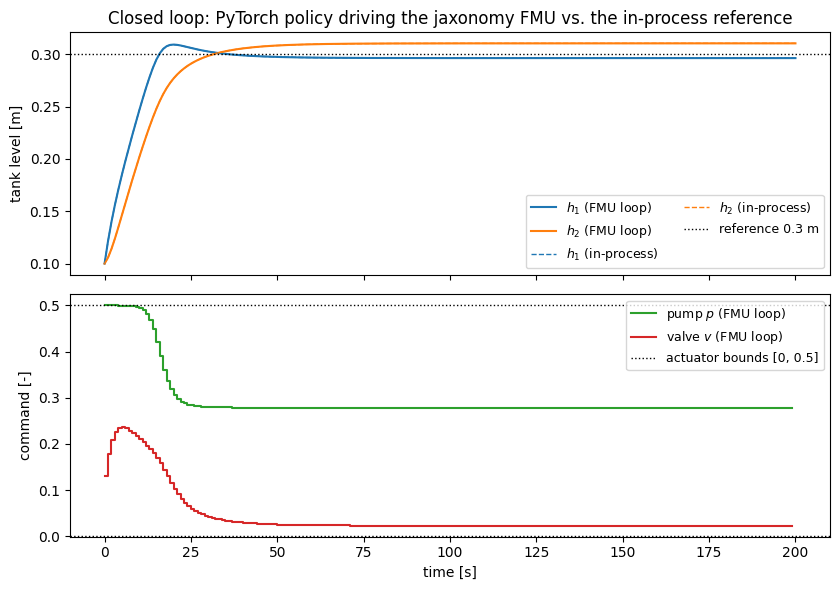

In [11]:
if not COSIM_OK:
    print("skipped (missing: " + ", ".join(MISSING) + ")")
else:
    t_x = np.arange(N_STEPS + 1) * TS
    t_u = np.arange(N_STEPS) * TS

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8.5, 6.0), sharex=True)
    ax1.plot(t_x, x_fmu[:, 0], color="tab:blue", label="$h_1$ (FMU loop)")
    ax1.plot(t_x, x_fmu[:, 1], color="tab:orange", label="$h_2$ (FMU loop)")
    ax1.plot(t_x, x_ref[:, 0], color="tab:blue", ls="--", lw=1,
             label="$h_1$ (in-process)")
    ax1.plot(t_x, x_ref[:, 1], color="tab:orange", ls="--", lw=1,
             label="$h_2$ (in-process)")
    ax1.axhline(REF[0], color="k", ls=":", lw=1, label="reference 0.3 m")
    ax1.set_ylabel("tank level [m]")
    ax1.set_title("Closed loop: PyTorch policy driving the jaxonomy FMU "
                  "vs. the in-process reference")
    ax1.legend(loc="lower right", ncols=2, fontsize=9)

    ax2.step(t_u, u_fmu[:, 0], where="post", color="tab:green",
             label="pump $p$ (FMU loop)")
    ax2.step(t_u, u_fmu[:, 1], where="post", color="tab:red",
             label="valve $v$ (FMU loop)")
    ax2.axhline(float(U_MAX[0]), color="k", ls=":", lw=1,
                label="actuator bounds [0, 0.5]")
    ax2.axhline(float(U_MIN[0]), color="k", ls=":", lw=1)
    ax2.set_xlabel("time [s]")
    ax2.set_ylabel("command [-]")
    ax2.legend(loc="upper right", fontsize=9)
    fig.tight_layout()
    plt.show()

**Figure 1.** Top: tank levels under the part-1 policy; solid = through the FMI boundary, dashed = in-process reference, dotted = the 0.3 m setpoints. The two loops are visually indistinguishable (they differ by at most $1.8\times10^{-8}$ m); both fill from 0.1 m to the setpoint band within ~40 s, with $h_2$ settling ~0.010 m above the reference — the policy's fixed point, as computed in §6. Bottom: the zero-order-held pump and valve commands from the FMU loop; the pump briefly rides its 0.5 upper bound during the fill, then relaxes toward the equilibrium value $\approx 0.28$, while the valve opens to ~0.24 early on — routing flow straight into tank 2 to raise $h_2$ faster — before closing to its equilibrium value of ~0.02.

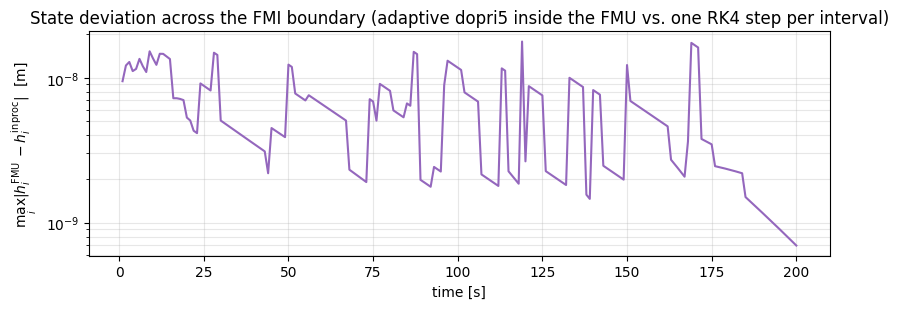

max deviation over the horizon: 1.783e-08 m at t = 119 s


In [12]:
if not COSIM_OK:
    print("skipped (missing: " + ", ".join(MISSING) + ")")
else:
    dev = np.abs(x_fmu - x_ref).max(axis=1)   # worst tank per step [m]
    fig, ax = plt.subplots(figsize=(8.5, 3.2))
    ax.semilogy(t_x[1:], dev[1:], color="tab:purple")
    ax.set_xlabel("time [s]")
    ax.set_ylabel(r"$\max_i |h_i^{\rm FMU} - h_i^{\rm in\,proc}|$  [m]")
    ax.set_title("State deviation across the FMI boundary "
                 "(adaptive dopri5 inside the FMU vs. one RK4 step per interval)")
    ax.grid(True, which="both", alpha=0.3)
    fig.tight_layout()
    plt.show()
    print(f"max deviation over the horizon: {dev.max():.3e} m at t = "
          f"{t_x[int(dev.argmax())]:.0f} s")

**Figure 2.** Per-step worst-tank deviation between the FMU-in-the-loop and in-process trajectories, log scale ($t = 0$ is omitted: both loops start from the exact same $\mathbf{x}_0$). The deviation stays inside a $10^{-9}$–$2\times10^{-8}$ m band over the whole horizon with **no secular growth** — feedback keeps each interval's truncation error from accumulating — topping out at $1.8\times10^{-8}$ m near $t = 119$ s. The step-to-step scatter is the adaptive solver re-choosing its internal steps every interval against the baseline's single fixed RK4 step. This curve *is* the solver-independence evidence: two unrelated integrators, one adaptive and one fixed-step, agree with each other to eight decimal places.

## 7. The honest cost of the boundary

The numbers printed in §5–6 deserve a direct statement: the FMI loop costs on the order of **0.1–0.2 s per communication step** on this machine, while the in-process loop costs **~70 µs per step** — a factor of roughly 2,000 (this run: 140 ms vs. 69 µs). Where does it go? Each `doStep` currently launches a fresh `jaxonomy.simulate` call over $[t_k, t_k + t_s]$: simulator-options construction and dispatch overhead per segment, plus FMI call marshalling through the C wrapper. (It is *not* recompilation — the underlying JAX computation is compiled once on the first step and reused; you can see this in the loop timing, where the first step carries the one-time JIT cost.)

This is the correct trade for what pattern C is *for*: a 200 s validation scenario completes in half a minute, a full day of plant time in under four hours. It is emphatically **not** a training boundary — a DPC training run like part 1's takes tens of thousands of rollout steps per epoch, and no gradients cross an FMU boundary anyway. Train in-process (patterns A/B), validate and certify across FMI (pattern C).

## 8. Closed-loop diagnostics

Every closed-loop notebook in this repo ends by running `jaxonomy.diagnostics` on the actuator commands — these catch silent failure modes (persistent saturation, bang-bang oscillation) that a clean-looking simulation can hide. We run both checks on both actuators from the FMU loop.

In [13]:
if not COSIM_OK:
    print("skipped (missing: " + ", ".join(MISSING) + ")")
else:
    for idx, name in enumerate(["pump", "valve"]):
        sat = analyze_saturation(
            u_fmu[:, idx],
            lower=float(U_MIN[idx]),
            upper=float(U_MAX[idx]),
            name=name,
        )
        osc = analyze_control_oscillation(u_fmu[:, idx], t_u, name=name)
        print(sat.message)
        print(osc.message)
        print()

pump: 4% at upper=0.5, 0% at lower=0. Total saturated: 4% of 200 samples.
pump: 1 sign changes over 199.00 s = 0.01 crossings/s

valve: 0% at upper=0.5, 0% at lower=0. Total saturated: 0% of 200 samples.
valve: 1 sign changes over 199.00 s = 0.01 crossings/s



Both actuators come back clean: no warnings triggered. The pump sits at its 0.5 upper bound for 4% of the horizon — entirely inside the initial fill transient, where commanding maximum flow from $h_0 = 0.1$ is exactly what a well-trained policy should do — far below the 50% threshold that flags a tuning bug. Sign-change rates of ~0.01 crossings/s on both commands rule out bang-bang behaviour; the sigmoid-bounded architecture of equation (3) produces smooth commands by construction.

## 9. Failure modes

Where this pattern breaks, concretely:

- **Communication step vs. the policy's training discretization.** The policy was trained as a discrete-time controller at $t_s = 1$ s (part 1 rolled it out through an RK4 model node with $h = 1$ s). The *FMU* advertises `canHandleVariableCommunicationStepSize = true` and will happily integrate 5 s intervals — but the *policy* has never seen a 5 s zero-order hold, and closed-loop behaviour degrades with no error message from either side. The FMI contract checks types and causality, not control-theoretic assumptions; the master's step size is a validation parameter you must hold at the policy's design value (or re-validate deliberately at off-design values).
- **One pythonfmu instance per process.** The embedded interpreter is a process-wide singleton (`Py_Initialize`); instantiating a second pythonfmu-based FMU — the same one again, or a different one — in one process is undefined behaviour. Re-running the §5 cell in a live kernel needs a kernel restart first, and batch studies (e.g., sweeping `REF`) need one subprocess per FMU instance.
- **The FMU is not self-contained.** pythonfmu's wrapper binary attaches to the importing process's Python and re-imports the slave script there, so the target environment must have jaxonomy and JAX installed at compatible versions — unlike a fully compiled (e.g., C-code) FMU, this artifact cannot be mailed to a bare Simulink box. For genuinely dependency-free delivery you need a compiled export path; within a Python-equipped bench (or a containerized one), pinning the environment alongside the `.fmu` is standard practice.
- **Skipping the output-priming step.** Forget the zero-length `doStep` from §5 and the first `getReal` silently returns 0.0 for both levels; the policy then reacts to an empty-tanks state that the plant is not actually in. The loop still runs and still converges — feedback hides the corruption of the first step — which is precisely why this failure is dangerous in a validation context. Prime the outputs, or cross-check $\mathbf{x}_0$ as we did in §5.

## 10. Exercises

1. **Rebuild with a different initial state.** The initial level is baked into the slave (`X0` in §3.1) — there is no FMI parameter for it. Change it to $(0.4, 0.2)$, rebuild (the build takes ~0.1 s; this per-scenario rebuild *is* the workaround), restart the kernel (§9, one-instance rule), and rerun. Does the policy still settle at the same fixed point?
2. **Probe the step-size failure mode.** Set `TS = 5.0` in the setup cell's constants (keeping `N_STEPS * TS` fixed at 200 s) and rerun both loops. Quantify the damage: how much does the tracking RMS degrade relative to the $t_s = 1$ s run, and does the FMU-vs-in-process deviation stay small even while both loops track worse? (It should — the boundary is not what breaks.)
3. **Predict, then verify, the deviation scaling.** The $1.8\times10^{-8}$ m deviation is dominated by the baseline's single-RK4-step truncation error, which scales as $O(h^5)$ locally. Predict the new max deviation if the in-process baseline takes two RK4 half-steps ($h = 0.5$ s) per interval, then modify `rk4_step`'s usage in §6 and check. (You should land near a 32× reduction until float64 rounding noise floors it.)
4. **Open-ended: a second master.** The whole point of the FMU is that nothing here is fmpy-specific. Import `TwoTankPlant.fmu` into another FMI 2.0 master — OMSimulator, Simulink's FMU import block, or a 20-line master of your own against `fmpy.fmi2` — replay the same command sequence `u_fmu`, and confirm you reproduce `x_fmu` to solver precision. If you have a real pump rig: this master loop, with `eval_policy` unchanged and `doStep` replaced by waiting out a real 1 s interval, is the skeleton of the HIL deployment.

## 11. Key takeaways

- `build_fmu` turns a jaxonomy diagram into an FMI 2.0 co-simulation FMU in a fraction of a second, and `fmpy.validation.validate_fmu` returning an **empty problem list** is the tool-neutral conformance receipt.
- The packaging conventions to remember: `Constant` blocks become the FMI inputs, exported *scalar* output ports give clean variable names, and the slave script must be self-contained because it is embedded verbatim and re-imported at instantiate time.
- FMU-in-the-loop and in-process trajectories agree to $1.8\times10^{-8}$ m over 200 steps *with different integrators on each side* — the deviation measures solver-choice sensitivity, which is exactly what a validation workflow wants quantified, and the policy's steady-state offset passes through the boundary untouched.
- The boundary costs ~2,000× per step over in-process. Train and iterate in-process (patterns A/B); validate, certify, and prep for HIL across FMI (pattern C).
- No gradients cross an FMU boundary — if you need them, that is part 2's pattern, not a missing feature here.

**Next steps.** Part 1 ([policy export](pinn_across_stacks_part_1_policy_export.ipynb)) trains the policy used here and validates it in-process; part 2 ([neural DAE](pinn_across_stacks_part_2_neural_dae.ipynb)) shows gradients crossing the same framework boundary. The [FMI export round-trip](fmi_export_roundtrip.ipynb) notebook exports a *controller* instead of a plant and re-imports FMUs into jaxonomy via `ModelicaFMU`. For a jaxonomy-native DPC treatment of this same plant, see [DPC two-tank reference tracking](dpc_two_tank_reference_tracking.ipynb).

## References

1. Blochwitz, T., Otter, M., et al., "Functional Mockup Interface 2.0: The Standard for Tool independent Exchange of Simulation Models," *Proceedings of the 9th International Modelica Conference*, 2012. FMI 2.0 specification: [fmi-standard.org](https://fmi-standard.org/).
2. `fmpy` — FMI simulation and validation library, Dassault Systèmes: [github.com/CATIA-Systems/FMPy](https://github.com/CATIA-Systems/FMPy).
3. `pythonfmu` — Python-driven FMU export, NTNU-IHB: [github.com/NTNU-IHB/PythonFMU](https://github.com/NTNU-IHB/PythonFMU). Hatledal, L. I., Collonval, F., and Zhang, H., "Enabling Python Driven Co-Simulation Models with PythonFMU," *Proceedings of the 34th European Council for Modeling and Simulation (ECMS)*, 2020.
4. NEUROMANCER — Drgoňa, J., Tuor, A., et al., *NEUROMANCER: Neural Modules with Adaptive Nonlinear Constraints and Efficient Regularizations*, PNNL: [github.com/pnnl/neuromancer](https://github.com/pnnl/neuromancer). The two-tank system is `neuromancer.psl` `systems["TwoTank"]`.
5. Drgoňa, J., Kiš, K., Tuor, A., Vrabie, D., and Klaučo, M., "Differentiable predictive control: Deep learning alternative to explicit model predictive control for unknown nonlinear systems," *Journal of Process Control*, 116:80–92, 2022.